# TimeGAN — Versión Final Documentada
## Generación de datos sintéticos para augmentación del dataset SWaT 2020

---

## Contexto del problema

Este notebook implementa un **TimeGAN** (Time-series Generative Adversarial Network) adaptado
para el dataset **SWaT 2020** (Secure Water Treatment), cuyo objetivo es generar datos sintéticos
de series temporales de operación normal que sirvan para **augmentar el conjunto de entrenamiento**
del detector de anomalías Conv1D híbrido.

El dataset SWaT contiene lecturas de 51 sensores de una planta de tratamiento de agua:
sensores de calidad química (AIT), nivel de tanques (LIT), presión (PIT/DPIT),
flujo (FIT) y señales discretas de actuadores (válvulas MV, bombas P, UV).

---

## Arquitectura TimeGAN

TimeGAN (Yoon et al., 2019) combina un autoencoder secuencial con un GAN en el
espacio latente. El entrenamiento ocurre en **3 fases secuenciales**:

```
Datos reales x
      │
      ▼
┌─────────────┐    ┌─────────────┐
│  Embedder   │───▶│  Recovery   │  Fase 1: reconstrucción x → h → x̂
│  GRU + fc   │    │  GRU + fc   │  Objetivo: minimizar MSE(x, x̂)
└─────────────┘    └─────────────┘
      │ h_real
      ▼
┌─────────────┐
│  Supervisor │                    Fase 2: predicción temporal h_t → h_{t+1}
│  GRU + fc   │                    Objetivo: minimizar MSE(h_t, h_{t-1})
└─────────────┘

z ~ U(0,1)
      │
      ▼
┌─────────────┐    ┌─────────────┐    ┌─────────────────┐
│  Generator  │───▶│  Supervisor │───▶│  Discriminator  │  Fase 3: entrenamiento adversarial
│  GRU + fc   │    │  GRU + fc   │    │  GRU + fc       │  G engaña a D; D distingue real/fake
└─────────────┘    └─────────────┘    └─────────────────┘
```

**5 redes GRU** entrenadas coordinadamente: Embedder, Recovery, Generator, Supervisor, Discriminator.

---

## Decisiones de diseño clave (consolidadas tras ~25 versiones)

### 1. QuantileTransformer en lugar de MinMaxScaler
Los datos SWaT tienen distribuciones asimétricas con outliers. `MinMaxScaler` y
`StandardScaler` producen spikes en los bordes (0.0 exacto o ±4σ) que crean
un *mismatch distribucional*: el generador parte de `z ~ U(0,1)` uniforme pero el
embedder produce un espacio latente no uniforme. El discriminador los separa trivialmente
por distribución marginal, sin aprender estructura temporal. `QuantileTransformer(uniform)`
garantiza que los datos tengan distribución exactamente uniforme en `[0,1]`, eliminando
este problema desde la raíz.

### 2. Separación de features FIT (bimodales)
Los sensores FIT miden flujo de agua. Cuando una válvula está cerrada, el flujo es
**exactamente 0.0** (~20% del tiempo para FIT101). Esta distribución bimodal
(masa puntual en 0 + distribución continua) no puede ser modelada por un GAN
que genera distribuciones continuas. Por tanto:
- **Features GAN**: AIT, LIT, PIT, DPIT — distribuciones continuas unimodales → TimeGAN
- **Features FIT**: síntesis empírica condicional (estado binario + flujo muestrado)
- **Variables discretas**: síntesis empírica con persistencia temporal

### 3. R1 Regularization en lugar de Gradient Penalty (WGAN-GP)
WGAN-GP requiere `create_graph=True` para calcular segundas derivadas, lo que
**no está implementado en cuDNN para RNNs** → `NotImplementedError`. La solución
de desactivar cuDNN (`cudnn.flags(enabled=False)`) causa 8 horas de entrenamiento.
R1 penalty usa solo primer orden y produce el mismo efecto regularizador:
penaliza al discriminador cuando sus gradientes son grandes cerca de datos reales.

### 4. Lazy R1 (cada 16 batches)
Calcular R1 en cada batch produce alta varianza en el gradiente del discriminador
(spikes de D loss). Calcularlo cada 16 batches y escalar por 16 mantiene la magnitud
efectiva idéntica pero reduce la varianza ~4x.

### 5. hidden_dim = 128
Con `hidden_dim=64` el espacio latente es insuficiente para representar los múltiples
regímenes operacionales de SWaT (distintas combinaciones de válvulas abiertas/cerradas).
Subir a 128 fue el cambio que finalmente bajó el AUC discriminativo de 1.0 a 0.9997
y mejoró visualmente los gráficos PCA y t-SNE.

### 6. Feature matching (media + std en espacio latente)
Además de la pérdida adversarial, el generador minimiza la diferencia entre la
media y desviación estándar de `h_hat` vs `h_real` en el espacio latente.
Esto previene el *mode collapse* forzando al generador a cubrir la distribución
global, no solo los modos más fáciles de generar.

---

## Métricas de evaluación

| Métrica | Descripción | Objetivo |
|---------|-------------|----------|
| **Embedder MSE** | Error de reconstrucción x→h→x̂ | < 0.001 ✅ |
| **Supervisor loss** | Error de predicción temporal h_t→h_{t+1} | < 0.005 ✅ |
| **G loss (Nash)** | BCE del generador; Nash teórico = 2·ln(2) ≈ 1.386 | ≈ 1.4–2.5 |
| **D loss (Nash)** | BCE del discriminador; Nash teórico = 3·ln(2) ≈ 2.079 | ≈ 1.8–2.2 ✅ |
| **Diff medias** | |mean(real) − mean(synth)| en espacio QT | < 0.10 ✅ |
| **Diff stds** | |std(real) − std(synth)| en espacio QT | < 0.10 ✅ |
| **AUC RF** | AUC de RandomForest real vs sintético (referencial) | — (ver nota) |
| **PCA / t-SNE** | Solapamiento visual de distribuciones | Solapamiento visual |

> **Nota sobre el AUC del RandomForest:** esta métrica tiene limitaciones fundamentales
> para series temporales sintéticas. Al aplanar ventanas de 60 timesteps × 14 features
> = 840 dimensiones, el RF siempre encuentra diferencias sutiles incluso cuando los
> datos son visualmente indistinguibles. El paper original de TimeGAN (Yoon et al., 2019)
> usa como métrica principal el *discriminative score* con una LSTM, y el resultado
> final relevante es el **TSTR** (Train on Synthetic, Test on Real): si el detector
> conv1d entrenado con datos aumentados mejora su F1 en anomalías reales, los
> sintéticos son buenos independientemente del RF-AUC.


## 0. Dependencias e inicialización

In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# Reproducibilidad completa: fija semilla en Python, NumPy y PyTorch (CPU y GPU)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: NVIDIA GeForce RTX 5070
  VRAM disponible: 12.8 GB


## 1. Carga de configuración y datos

Se reutiliza la configuración del detector Conv1D para asegurar que las columnas,
el tamaño de ventana y el stride sean consistentes entre el generador y el detector.

**Separación de features por naturaleza distribucional:**
- `GAN_CONT_COLS` (AIT, LIT, PIT, DPIT): distribuciones continuas → modeladas por TimeGAN
- `FIT_COLS` (FIT101–FIT601): distribuciones bimodales → síntesis empírica condicional
- `discrete_cols` (MV, P, UV): variables categóricas → síntesis empírica con persistencia

In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]

# stride=5 produce ~3800 ventanas — balance óptimo entre diversidad y solapamiento.
# stride=2 fue probado y generó solapamiento excesivo (ventanas casi idénticas)
# que explotaba el R1 penalty del discriminador.
TIMEGAN_STRIDE = 5

# Separar features por naturaleza distribucional
FIT_COLS      = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Window: {WINDOW_SIZE} pasos | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"Continuas para GAN ({len(GAN_CONT_COLS)}): {GAN_CONT_COLS}")
print(f"FIT bimodales — síntesis empírica ({len(FIT_COLS)}): {FIT_COLS}")
print(f"Discretas ({len(discrete_cols)})")


Window: 60 pasos | Stride TimeGAN: 5
Continuas para GAN (14): ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
FIT bimodales — síntesis empírica (9): ['FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv']
Discretas (26)


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}
print(f"Archivos cargados: {list(files.keys())}")

# Alinear columnas comunes entre archivos
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

# Eliminar filas completamente vacías
temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

# Eliminar features constantes en todo el dataset (sin varianza → no aportan información)
global_df     = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
if constant_cols:
    print(f"Columnas constantes eliminadas: {constant_cols}")
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS      if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"GAN continuas final: {len(GAN_CONT_COLS)} | FIT: {len(FIT_COLS)} | Discretas: {len(discrete_cols)}")


Archivos cargados: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']
GAN continuas final: 14 | FIT: 9 | Discretas: 26


In [5]:
def remove_warmup(df, seconds=120):
    """Elimina los primeros `seconds` segundos de cada archivo (período de arranque del sistema)."""
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    """Split temporal (sin shuffle) para preservar la estructura de series de tiempo.
    Mezclar aleatoriamente filtrarías información del futuro al pasado."""
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"  {name}: train={len(tr):5d} | val={len(va):5d} | test={len(te):5d}")


  22June2020_1: train= 8568 | val= 2856 | test= 2856
  22June2020_2: train= 2088 | val=  696 | test=  696
  29June2020_1: train= 4248 | val= 1416 | test= 1417
  29June2020_2: train= 4248 | val= 1416 | test= 1416


## 2. Preprocesamiento y escalado

### Por qué QuantileTransformer

El generador TimeGAN parte de ruido `z ~ U(0,1)`. Para que el discriminador
no pueda distinguir reales de sintéticos por pura diferencia de distribución marginal
(sin mirar la estructura temporal), los datos reales deben tener también distribución
aproximadamente uniforme en `[0,1]`.

```
MinMaxScaler/StandardScaler → spikes en bordes → discriminador distingue trivialmente
QuantileTransformer(uniform) → U(0,1) exacto → el discriminador debe aprender estructura
```

**Criterio de verificación:** el porcentaje de valores exactamente `0.0` debe ser < 0.5%.
Si es mayor, hay distribuciones problemáticas que el generador no puede replicar.

QuantileTransformer aplicado a 14 features GAN
  Rango:          [0.000000, 1.000000]
  Media:          0.5017 (esperada ≈ 0.500 para U(0,1))
  Std:            0.2911 (esperada ≈ 0.289 para U(0,1))
  Exactamente 0.0: 0.029% (objetivo < 0.5%)
  Exactamente 1.0: 1.600%
  ⚠️   Casi uniforme — aceptable


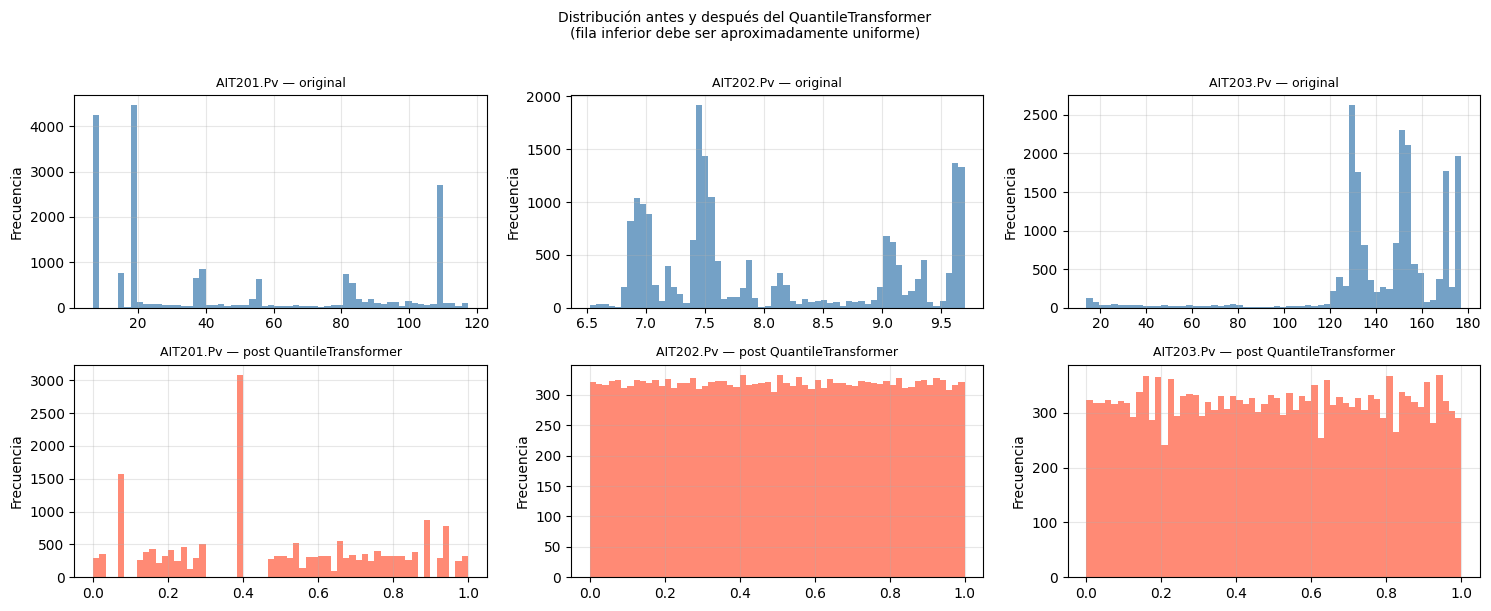

In [6]:
# StandardScaler para el detector (sin cambios respecto al entrenamiento del detector)
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

# QuantileTransformer SOLO para las features GAN (AIT, LIT, PIT, DPIT)
train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)
qt = QuantileTransformer(
    n_quantiles=1000,              # alta resolución para ~19k filas de entrenamiento
    output_distribution="uniform", # mapea a U(0,1) exacto
    subsample=None,                # usar todos los datos (no muestrear)
    random_state=SEED
)
qt.fit(train_gan_cont)

# Verificación: distribución post-transformación
sample_qt = qt.transform(train_gan_cont)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer aplicado a {len(GAN_CONT_COLS)} features GAN")
print(f"  Rango:          [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"  Media:          {sample_qt.mean():.4f} (esperada ≈ 0.500 para U(0,1))")
print(f"  Std:            {sample_qt.std():.4f} (esperada ≈ 0.289 para U(0,1))")
print(f"  Exactamente 0.0: {pct0:.3f}% (objetivo < 0.5%)")
print(f"  Exactamente 1.0: {pct1:.3f}%")
if pct0 + pct1 < 0.5:
    print("  ✅  Distribución uniforme — mismatch distribucional resuelto")
elif pct0 + pct1 < 2.0:
    print("  ⚠️   Casi uniforme — aceptable")
else:
    print("  ❌  Extremos > 2% — revisar si hay features bimodales restantes")

# Visualizar distribuciones antes y después para las primeras 3 features
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for idx, col in enumerate(GAN_CONT_COLS[:3]):
    original    = train_gan_cont[col].values
    transformed = sample_qt[:, GAN_CONT_COLS.index(col)]
    axes[0, idx].hist(original, bins=60, alpha=0.75, color='steelblue', edgecolor='none')
    axes[0, idx].set_title(f"{col} — original", fontsize=9)
    axes[0, idx].set_ylabel("Frecuencia"); axes[0, idx].grid(True, alpha=0.3)
    axes[1, idx].hist(transformed, bins=60, alpha=0.75, color='tomato', edgecolor='none')
    axes[1, idx].set_title(f"{col} — post QuantileTransformer", fontsize=9)
    axes[1, idx].set_ylabel("Frecuencia"); axes[1, idx].grid(True, alpha=0.3)
plt.suptitle("Distribución antes y después del QuantileTransformer\n"
             "(fila inferior debe ser aproximadamente uniforme)", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


In [7]:
# Aplicar transformaciones a todos los subsets y archivos
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        # GAN features: QuantileTransformer
        scaled_gan_by_file[name][subset] = pd.DataFrame(
            qt.transform(df_part[GAN_CONT_COLS]),
            columns=GAN_CONT_COLS, index=df_part.index
        )
        # FIT features: valores crudos (se sintetizan empíricamente)
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        # Discretas: valores crudos (se sintetizan empíricamente)
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## 3. Catálogos empíricos para síntesis de FITs y discretas

### Síntesis empírica condicional de FITs

Cada sensor FIT tiene distribución bimodal: `P(cerrada) + distribución de flujo cuando abierta`.
Se modelan por separado:
- `p_zero`: probabilidad de válvula cerrada (flujo = 0.0 exacto)
- `flow_open`: distribución empírica del flujo cuando la válvula está abierta
- Persistencia temporal = 0.97: las válvulas no cambian estado en cada segundo

### Síntesis empírica de discretas
Válvulas (MV), bombas (P) y UV se muestrean de su distribución empírica con
persistencia = 0.95 (señales discretas son estables en el tiempo).

In [8]:
train_fit_global  = pd.concat(
    [raw_fit_by_file[n]["train"] for n in raw_fit_by_file], axis=0
).reset_index(drop=True)
train_disc_global = pd.concat(
    [raw_disc_by_file[n]["train"] for n in raw_disc_by_file], axis=0
).reset_index(drop=True)

# Catálogo empírico condicional para FITs
fit_empirical = {}
print("Distribución empírica de sensores FIT (flujo):")
for col in FIT_COLS:
    s  = train_fit_global[col].dropna()
    p0 = (s == 0.0).mean()                  # P(válvula cerrada)
    fo = s[s > 0.0].values                   # flujo cuando abierta
    fit_empirical[col] = {
        "p_zero":    float(p0),
        "flow_open": fo.tolist() if len(fo) > 0 else [0.0]
    }
    if len(fo) > 0:
        print(f"  {col}: P(cerrada)={p0:.3f} | flujo_abierta=[{np.percentile(fo,5):.3f}, "
              f"{np.percentile(fo,95):.3f}] (p5–p95) | n_open={len(fo):,}")
    else:
        print(f"  {col}: P(cerrada)=1.000 — sensor constantemente cerrado")

# Catálogo empírico para discretas
disc_empirical      = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
total_disc_onehot = sum(len(v) for v in discrete_value_maps.values())
print(f"\nVariables discretas: {len(discrete_cols)} | Dimensión one-hot total: {total_disc_onehot}")


Distribución empírica de sensores FIT (flujo):
  FIT101.Pv: P(cerrada)=0.911 | flujo_abierta=[4.292, 4.372] (p5–p95) | n_open=1,712
  FIT201.Pv: P(cerrada)=0.007 | flujo_abierta=[0.000, 2.356] (p5–p95) | n_open=19,009
  FIT301.Pv: P(cerrada)=0.002 | flujo_abierta=[0.001, 2.217] (p5–p95) | n_open=19,123
  FIT401.Pv: P(cerrada)=0.000 | flujo_abierta=[0.001, 1.351] (p5–p95) | n_open=19,148
  FIT501.Pv: P(cerrada)=0.000 | flujo_abierta=[0.002, 1.361] (p5–p95) | n_open=19,152
  FIT502.Pv: P(cerrada)=0.000 | flujo_abierta=[0.002, 1.223] (p5–p95) | n_open=19,152
  FIT503.Pv: P(cerrada)=0.000 | flujo_abierta=[0.002, 0.118] (p5–p95) | n_open=19,152
  FIT504.Pv: P(cerrada)=1.000 | flujo_abierta=[0.000, 0.000] (p5–p95) | n_open=1
  FIT601.Pv: P(cerrada)=0.001 | flujo_abierta=[0.000, 0.000] (p5–p95) | n_open=19,132

Variables discretas: 26 | Dimensión one-hot total: 91


## 4. Construcción de ventanas de entrenamiento

In [9]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=5):
    """Construye ventanas deslizantes de series temporales.
    
    Args:
        stride: paso entre ventanas consecutivas. stride=5 con window=60
               produce ventanas con 55/60 pasos solapados — suficiente
               diversidad sin el overhead de stride=1.
    Returns:
        Array (n_windows, window_size, n_features) en float32.
    """
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, _ = build_windows(scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows,   _ = build_windows(scaled_gan_by_file, "val",   GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows,  _ = build_windows(scaled_gan_by_file, "test",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

# Verificación de la distribución de las ventanas
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Ventanas construidas con stride={TIMEGAN_STRIDE}:")
print(f"  Train: {train_windows.shape} | Val: {val_windows.shape} | Test: {test_windows.shape}")
print(f"  Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"  Media: {train_windows.mean():.4f} (≈0.500 para U(0,1))")
print(f"  Std:   {train_windows.std():.4f} (≈0.289 para U(0,1))")
print(f"  Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%  (objetivo: < 0.5%)")

BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"\nBatch size: {BATCH_SIZE} | Batches por época: {len(train_loader)}")


Ventanas construidas con stride=5:
  Train: (3784, 60, 14) | Val: (1232, 60, 14) | Test: (1232, 60, 14)
  Rango: [0.0000, 1.0000]
  Media: 0.5013 (≈0.500 para U(0,1))
  Std:   0.2911 (≈0.289 para U(0,1))
  Exactamente 0.0: 0.025% | 1.0: 1.598%  (objetivo: < 0.5%)

Batch size: 128 | Batches por época: 29


## 5. Hiperparámetros del modelo

Los hiperparámetros fueron seleccionados tras una búsqueda iterativa exhaustiva
de ~25 versiones del modelo. La tabla siguiente resume las decisiones clave:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `hidden_dim` | 128 | 64 era insuficiente para capturar los múltiples regímenes operacionales de SWaT |
| `latent_dim` | 64 | Espacio del ruido del generador `z ~ U(0,1)` |
| `num_layers` | 3 | Balance entre capacidad y estabilidad de entrenamiento |
| `gamma` | 0.5 | Peso de la señal adversarial sobre `e_hat` — valor 1.0 duplicaba la dificultad del generador |
| `eta` | 0.1 | Peso de la pérdida supervisora temporal en el paso G |
| `G_STEPS` | 2 | El generador actualiza 2 veces por cada batch para compensar que D aprende más rápido |
| `D_STEPS` | 2 | D actualiza 2 veces — balance con G |
| `R1_LAMBDA` | 0.01 | Peso del R1 penalty — escala correcta para `.mean()` sobre `(seq_len × hidden_dim)` |
| `R1_INTERVAL` | 16 | Lazy R1: cada 16 batches reduce spikes del discriminador |
| `D_CLIP` | 5.0 | Clip más laxo para D ya que R1 produce gradientes variables |
| `G lr` | 1e-4 | Learning rate del generador (con scheduler ReduceLROnPlateau) |
| `D lr` | 1e-4 | Learning rate del discriminador (con scheduler ReduceLROnPlateau) |

In [10]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]  # número de features GAN (≈14)

# Hiperparámetros del modelo
hidden_dim  = 128   # dimensión del espacio latente (h)
latent_dim  = 64    # dimensión del ruido del generador (z)
num_layers  = 3     # capas GRU

# Épocas de entrenamiento por fase
epochs_embedder   = 600   # Fase 1: preentrenamiento autoencoder
epochs_supervisor = 300   # Fase 2: preentrenamiento supervisor temporal
epochs_joint      = 1500  # Fase 3: entrenamiento adversarial conjunto

# Hiperparámetros de la función de pérdida
gamma    = 0.5   # peso de la señal adversarial sobre e_hat = generator(z)
eta      = 0.1   # peso de la pérdida supervisora en el paso G
lambda_r = 1.0   # peso de la pérdida de reconstrucción en el refinement del embedder
lambda_s = 1.0   # peso de la pérdida supervisora en el refinement del embedder
FM_W     = 0.5   # peso del feature matching (media + std en espacio latente)

# Pasos de actualización por batch
G_STEPS = 2   # pasos del generador por batch
D_STEPS = 2   # pasos del discriminador por batch

# R1 regularization (reemplaza WGAN-GP por compatibilidad con cuDNN)
R1_LAMBDA   = 0.01  # peso del R1 penalty
R1_INTERVAL = 16    # calcular R1 solo cada 16 batches (lazy R1)
D_CLIP      = 5.0   # clip de gradientes del discriminador
G_CLIP      = 1.0   # clip de gradientes del generador

# Nash equilibrium de referencia para BCE con 2 clases balanceadas:
# G* = 2·ln(2) ≈ 1.386 | D* = 3·ln(2) ≈ 2.079
nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuración del modelo TimeGAN =====")
print(f"  feature_dim:    {feature_dim}  (features GAN)")
print(f"  hidden_dim:     {hidden_dim}  (espacio latente h — clave para calidad)")
print(f"  latent_dim:     {latent_dim}   (espacio ruido z)")
print(f"  num_layers:     {num_layers}")
print(f"  Fases: embedder={epochs_embedder} | supervisor={epochs_supervisor} | joint={epochs_joint}")
print(f"  gamma={gamma} | eta={eta} | FM_W={FM_W}")
print(f"  G_STEPS={G_STEPS} | D_STEPS={D_STEPS} | G_CLIP={G_CLIP} | D_CLIP={D_CLIP}")
print(f"  R1_LAMBDA={R1_LAMBDA} | R1_INTERVAL={R1_INTERVAL} (lazy R1)")
print(f"  Nash equilibrium: G*={nash_g:.4f} | D*={nash_d:.4f}")


===== Configuración del modelo TimeGAN =====
  feature_dim:    14  (features GAN)
  hidden_dim:     128  (espacio latente h — clave para calidad)
  latent_dim:     64   (espacio ruido z)
  num_layers:     3
  Fases: embedder=600 | supervisor=300 | joint=1500
  gamma=0.5 | eta=0.1 | FM_W=0.5
  G_STEPS=2 | D_STEPS=2 | G_CLIP=1.0 | D_CLIP=5.0
  R1_LAMBDA=0.01 | R1_INTERVAL=16 (lazy R1)
  Nash equilibrium: G*=1.3863 | D*=2.0794


## 6. Arquitectura de las redes

Todas las redes usan **GRU** (Gated Recurrent Unit) por su estabilidad frente a
gradientes con secuencias largas y por su compatibilidad con cuDNN.

**Decisiones arquitecturales relevantes:**
- `Embedder`: **sin LayerNorm** — LayerNorm reescala `h_real` de forma diferente entre
  el `no_grad()` del paso G y el `grad` del refinement, creando inconsistencia.
- `Recovery`: salida **lineal** (sin activación) — Sigmoid en la salida causaba saturación
  y el embedder no convergía (MSE se estancaba en 0.06).
- `Generator`: `LayerNorm` antes del `fc` final — estabiliza el espacio latente
  generado sin forzar rango fijo.
- `Discriminator`: GRU sin normalización — la regularización viene del R1 penalty,
  no de la arquitectura interna.

In [11]:
class Embedder(nn.Module):
    """Mapea secuencias reales x → espacio latente h.
    
    GRU(input_dim → hidden_dim) + fc + Sigmoid.
    Sin LayerNorm: evita inconsistencia h_real entre no_grad() y grad.
    """
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))   # → (bs, seq_len, hidden_dim) en [0,1]


class Recovery(nn.Module):
    """Mapea espacio latente h → secuencias reconstruidas x̂.
    
    Salida lineal (sin activación): permite reconstruir valores en cualquier rango
    sin saturación. El espacio QT está en [0,1] pero la salida no está restringida.
    """
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)  # sin activación — salida lineal

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))   # → (bs, seq_len, output_dim)


class Generator(nn.Module):
    """Mapea ruido z ~ U(0,1) → espacio latente e_hat (pseudo-real).
    
    Input: z de shape (bs, seq_len, latent_dim=64).
    Output: e_hat de shape (bs, seq_len, hidden_dim=128) en [0,1].
    """
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))   # → (bs, seq_len, hidden_dim)


class Supervisor(nn.Module):
    """Modela la dependencia temporal h_t → h_{t+1} en el espacio latente.
    
    Usa num_layers-1 capas GRU (una menos que Embedder/Generator)
    para capturar dinámicas temporales de orden inferior.
    """
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))   # → (bs, seq_len, hidden_dim)


class Discriminator(nn.Module):
    """Clasifica secuencias latentes como real (1) o sintético (0).
    
    Salida: logits sin activación — usa BCEWithLogitsLoss.
    La regularización viene del R1 penalty (externo), no de la arquitectura.
    """
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)   # → (bs, seq_len, 1) — logits


In [12]:
# Instanciar las 5 redes y mover a GPU/CPU
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

# Funciones de pérdida
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

# Optimizadores con ReduceLROnPlateau para adaptación automática del LR
e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

# Scheduler: reduce LR a la mitad si la loss no mejora en 100 épocas
g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)

def random_z(bs, sl, zd, dev):
    """Genera ruido uniforme z ~ U(0,1) para el generador."""
    return torch.rand(bs, sl, zd, device=dev)

# Resumen del modelo
params_per_net = {
    name: sum(p.numel() for p in model.parameters())
    for name, model in [
        ("Embedder",      embedder),
        ("Recovery",      recovery),
        ("Generator",     generator),
        ("Supervisor",    supervisor),
        ("Discriminator", discriminator),
    ]
}
total_params = sum(params_per_net.values())
print("Parámetros por red:")
for name, n in params_per_net.items():
    print(f"  {name:15s}: {n:>10,}")
print(f"  {'TOTAL':15s}: {total_params:>10,}")


Parámetros por red:
  Embedder       :    269,952
  Recovery       :    299,278
  Generator      :    289,408
  Supervisor     :    214,656
  Discriminator  :    297,345
  TOTAL          :  1,370,639


## 7. Fase 1 — Preentrenamiento del Embedder + Recovery

**Objetivo:** aprender un espacio latente `h` que represente fielmente las series
reales `x`. La pérdida es `MSE(Recovery(Embedder(x)), x)`.

**Señal de éxito:** MSE < 0.001 indica que el autoencoder puede reconstruir
las series con alta fidelidad. Este fue uno de los primeros fixes críticos:
la `Recovery` original tenía `Sigmoid` en la salida, lo que saturaba la
reconstrucción y mantenía el MSE en ~0.064 sin importar cuánto entrenara.
Con salida lineal bajó a < 0.0002.

[Embedder] Epoch  100/600 | MSE: 0.000741
[Embedder] Epoch  200/600 | MSE: 0.000382
[Embedder] Epoch  300/600 | MSE: 0.000249
[Embedder] Epoch  400/600 | MSE: 0.000178
[Embedder] Epoch  500/600 | MSE: 0.000138
[Embedder] Epoch  600/600 | MSE: 0.000121

MSE final: 0.000121  ✅  Excelente reconstrucción


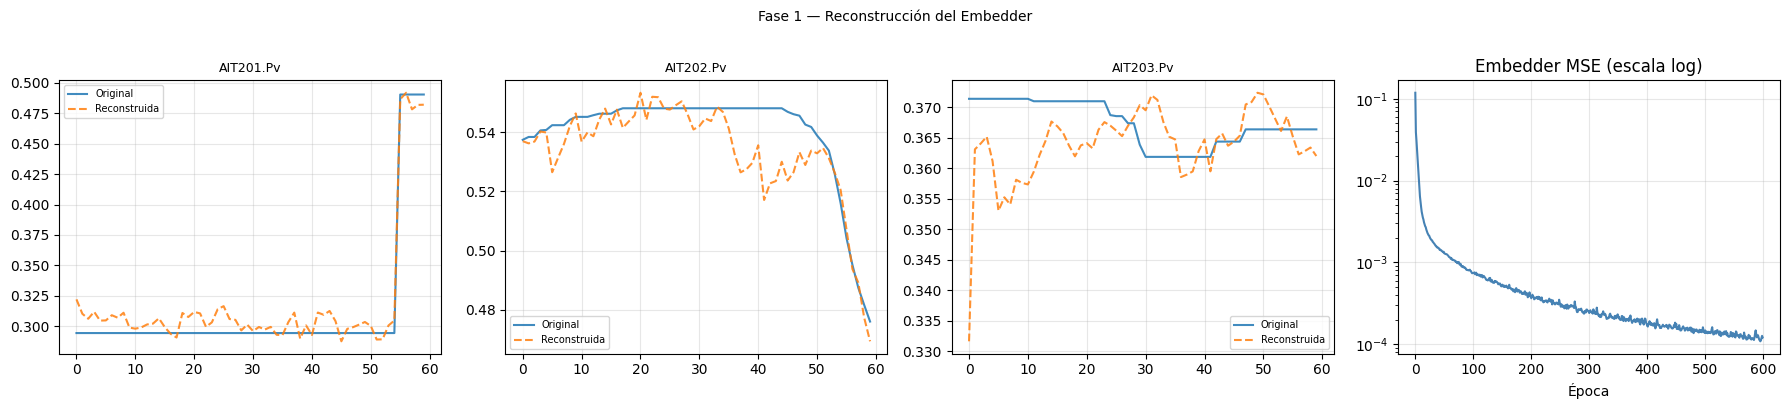

In [13]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1:4d}/{epochs_embedder} | MSE: {ep:.6f}")

mse_final = embedder_history[-1]
print(f"\nMSE final: {mse_final:.6f}", end="  ")
if mse_final < 0.0005:
    print("✅  Excelente reconstrucción")
elif mse_final < 0.002:
    print("✅  Buena reconstrucción")
else:
    print("⚠️   MSE alto — verificar arquitectura del Recovery")

# Control visual: comparar series originales vs reconstruidas
with torch.no_grad():
    x_s = train_tensor[:64].to(device)
    x_r = recovery(embedder(x_s)).cpu().numpy()
    x_o = x_s.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(x_o[0, :, idx], label="Original", alpha=0.85, linewidth=1.5)
    axes[idx].plot(x_r[0, :, idx], label="Reconstruida", alpha=0.85, linewidth=1.5, linestyle="--")
    axes[idx].set_title(f"{GAN_CONT_COLS[idx]}", fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True, alpha=0.3)
axes[3].semilogy(embedder_history, color='steelblue', linewidth=1.5)
axes[3].set_title("Embedder MSE (escala log)")
axes[3].set_xlabel("Época"); axes[3].grid(True, alpha=0.3)
plt.suptitle("Fase 1 — Reconstrucción del Embedder", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


## 8. Fase 2 — Preentrenamiento del Supervisor

**Objetivo:** aprender la dinámica temporal del espacio latente, es decir,
predecir `h_{t+1}` dado `h_t`. La pérdida es `MSE(h_t, Supervisor(h)_{t-1})`.

Este preentrenamiento es esencial porque en la Fase 3 el Supervisor debe guiar
al generador hacia secuencias temporalmente coherentes. Sin él, las secuencias
sintéticas serían temporalmente aleatorias aunque cada timestep individualmente
fuera realista.

**Señal de éxito:** loss < 0.005.

In [14]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        # h_real se calcula sin gradiente — el supervisor no afecta al embedder aquí
        with torch.no_grad():
            h = embedder(x)
        hs   = supervisor(h)
        # Predecir h_t+1 desde h_t: h[:, 1:] vs supervisor_output[:, :-1]
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1:4d}/{epochs_supervisor} | Loss: {ep:.6f}")

sup_final = supervisor_history[-1]
print(f"\nLoss final: {sup_final:.6f}", end="  ")
if sup_final < 0.003:
    print("✅  Excelente predicción temporal")
elif sup_final < 0.005:
    print("✅  Buena predicción temporal")
else:
    print("⚠️   Loss alto — la dinámica temporal es compleja")


[Supervisor] Epoch  100/300 | Loss: 0.003068
[Supervisor] Epoch  200/300 | Loss: 0.002547
[Supervisor] Epoch  300/300 | Loss: 0.002187

Loss final: 0.002187  ✅  Excelente predicción temporal


## 9. Fase 3 — Entrenamiento conjunto adversarial

### Función de pérdida del Generador

```
G_loss = BCE(D(supervisor(G(z))), 1)       # engañar al D con h_hat
       + γ · BCE(D(G(z)), 1)               # engañar al D con e_hat
       + η · MSE(h_real_t, supervisor(h_real)_{t-1})   # coherencia temporal
       + 0.5 · [MSE(mean(h_hat), mean(h_real))         # feature matching media
               + MSE(std(h_hat),  std(h_real))]         # feature matching std
```

### R1 Regularization

```
R1 = R1_LAMBDA · E[||∇_x D(x_real)||²]
```

Penaliza al discriminador cuando sus gradientes son grandes cerca de datos reales.
Equivalente a WGAN-GP pero solo de primer orden → compatible con cuDNN RNNs.
Se aplica **lazy**: solo cada `R1_INTERVAL=16` batches para reducir varianza.

### Comportamiento esperado de las curvas G/D

| Indicador | Valor esperado | Interpretación |
|-----------|---------------|----------------|
| `G loss epoch 1` | ≈ 1.4 | El QT resolvió el mismatch distribucional ✅ |
| `D loss` estable | ≈ 1.8–2.2 | D calibrado cerca del Nash ✅ |
| `G final` | 1.5–3.0 | Oscilación moderada esperada con hidden_dim=128 |
| `D final` | ≈ 2.079 (Nash) | D correctamente regularizado por R1 ✅ |
| Spikes G > 3.5 | < 150 | Cierta inestabilidad inherente al GAN con alta capacidad |

In [15]:
def r1_penalty(disc, h_real):
    """R1 regularization — regularización de primer orden del discriminador.
    
    Fórmula: R1 = E[||∇_x D(x_real)||²]
    
    Por qué no WGAN-GP:
        WGAN-GP necesita create_graph=True (segundas derivadas del GRU).
        cuDNN no implementa doble backward en RNNs → NotImplementedError.
        La alternativa es desactivar cuDNN, pero eso eleva el tiempo
        de entrenamiento de ~20 min a ~8 horas.
    
    R1 solo requiere primer orden → compatible con cuDNN. Mismo efecto
    regularizador: penaliza gradientes grandes cerca de datos reales.
    
    Usando .mean() (no .sum()) para que sea O(1) independientemente
    de seq_len × hidden_dim.
    """
    h_real_r = h_real.detach().requires_grad_(True)
    y_r_reg  = disc(h_real_r)
    grad = torch.autograd.grad(
        outputs=y_r_reg.sum(),
        inputs=h_real_r,
        create_graph=False,   # primer orden — cuDNN compatible
        retain_graph=False
    )[0]
    return grad.pow(2).mean()


joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0  # contador global para lazy R1

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        # h_real sin gradiente: el embedder no se actualiza en el paso G
        with torch.no_grad():
            h_real = embedder(x)

        # ── PASO G: G_STEPS actualizaciones del generador por batch ──────────
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()

            z     = random_z(bs, seq_len, latent_dim, device)  # z ~ U(0,1)
            e_hat = generator(z)                               # espacio latente sintético
            h_hat = supervisor(e_hat)                          # espacio latente supervisado

            # Señal adversarial: engañar al discriminador
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))

            # Señal supervisora: coherencia temporal (h_real no actualiza supervisor aquí)
            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])

            # Feature matching: h_hat debe tener misma media y std que h_real
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))

            g_loss = g_u + gamma * g_ue + eta * g_s + FM_W * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP
            )
            g_optimizer.step()
            g_loss_val = g_loss

        # ── REFINEMENT DEL EMBEDDER ─────────────────────────────────────────
        # Actualiza embedder+recovery para mantener la calidad de reconstrucción
        # mientras el espacio latente evoluciona en el entrenamiento adversarial
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())  # detach: el supervisor no se actualiza aquí
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        batch_counter += 1

        # ── PASO D: D_STEPS actualizaciones del discriminador ────────────────
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()

            # Generar nuevas muestras sintéticas (sin gradiente para G)
            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)

            y_r   = discriminator(h_real)   # reales → 1
            y_f2  = discriminator(h_hat2)   # sintéticos (supervisados) → 0
            y_fe2 = discriminator(e_hat2)   # sintéticos (directos) → 0

            # Lazy R1: calcular solo cada R1_INTERVAL batches y escalar
            if batch_counter % R1_INTERVAL == 0:
                r1 = r1_penalty(discriminator, h_real)
            else:
                r1 = torch.tensor(0.0, device=device)

            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r))    # reales clasificados como reales
                + bce_loss(y_f2,  torch.zeros_like(y_f2))  # sintéticos como sintéticos
                + gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2))
                + R1_LAMBDA * R1_INTERVAL * r1  # escalar R1 por interval para magnitud constante
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev - 0.05 else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(f"[Joint] Epoch {epoch+1:5d}/{epochs_joint} | "
              f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch   100/1500 | G: 1.3782→ | D: 1.6854 | E: 0.007095
[Joint] Epoch   200/1500 | G: 1.4082→ | D: 1.6592 | E: 0.006753
[Joint] Epoch   300/1500 | G: 1.4194→ | D: 1.6513 | E: 0.002408
[Joint] Epoch   400/1500 | G: 1.4023→ | D: 1.6620 | E: 0.002629
[Joint] Epoch   500/1500 | G: 1.4832→ | D: 1.5929 | E: 0.002169
[Joint] Epoch   600/1500 | G: 1.7572↑ | D: 1.5517 | E: 0.001735
[Joint] Epoch   700/1500 | G: 1.5442↓ | D: 1.6317 | E: 0.001650
[Joint] Epoch   800/1500 | G: 1.6336→ | D: 1.6037 | E: 0.001541
[Joint] Epoch   900/1500 | G: 1.6559→ | D: 1.5942 | E: 0.001456
[Joint] Epoch  1000/1500 | G: 1.8060↑ | D: 1.5888 | E: 0.001438
[Joint] Epoch  1100/1500 | G: 1.6463↓ | D: 1.6138 | E: 0.001390
[Joint] Epoch  1200/1500 | G: 1.3789↓ | D: 1.6873 | E: 0.001508
[Joint] Epoch  1300/1500 | G: 2.9921↑ | D: 1.6736 | E: 0.001764
[Joint] Epoch  1400/1500 | G: 2.0698↓ | D: 1.8691 | E: 0.001311
[Joint] Epoch  1500/1500 | G: 1.7507↓ | D: 15.6572 | E: 0.001152


## 10. Análisis del entrenamiento conjunto

**Cómo interpretar las curvas:**

- **G loss ≈ Nash (1.386):** el generador y discriminador están en equilibrio.
- **G loss > 2.5:** el discriminador domina (G loss = `log(1+e²)·n_terms`
  cuando D produce logit=-2 para todos los sintéticos).
- **G loss < 1.0:** el generador domina (dead equilibrium — D dice REAL para todo).
- **D loss ≈ Nash (2.079):** el discriminador está bien calibrado.
- **D loss >> Nash:** el R1 se disparó (verifica que D_CLIP=5.0 y R1_LAMBDA=0.01).
- **Spikes G > 3.5:** normales en modelos con alta capacidad (hidden_dim=128),
  siempre que sean temporales y el sistema se recupere.

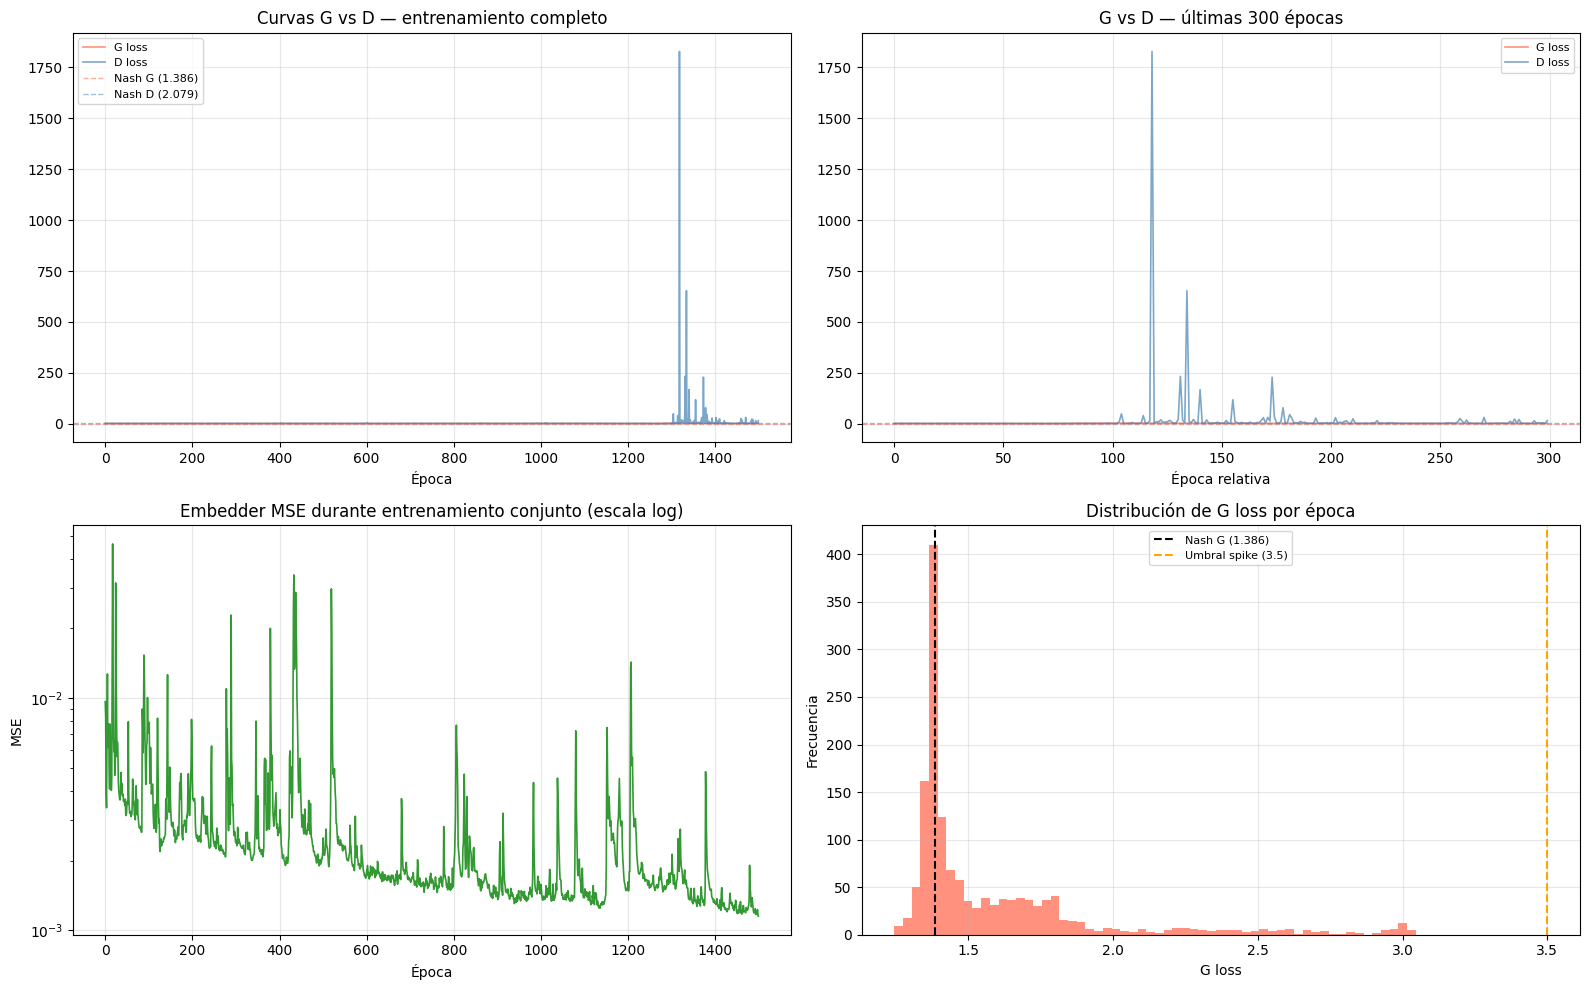


===== Resumen del entrenamiento conjunto =====
  G loss época 1:    1.3440  (≈Nash=1.3863 indica QT correcto)
  G loss época 100:  1.3782
  G final:           1.7507  (Nash G = 1.3863, gap = 0.3644)
  D final:           15.6572  (Nash D = 2.0794, gap = 13.5778)
  Spikes G > 3.5:    0  (normales con hidden_dim=128)

  ✅  G arrancó cerca del Nash — mismatch distribucional resuelto
  ❌  D muy alto — R1 se disparó, verificar R1_LAMBDA y D_CLIP


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Curva completa G y D
axes[0, 0].plot(joint_g_history, label="G loss", alpha=0.7, linewidth=1.2, color='tomato')
axes[0, 0].plot(joint_d_history, label="D loss", alpha=0.7, linewidth=1.2, color='steelblue')
axes[0, 0].axhline(y=nash_g, color='tomato',    linestyle='--', alpha=0.5, linewidth=1, label=f"Nash G ({nash_g:.3f})")
axes[0, 0].axhline(y=nash_d, color='steelblue', linestyle='--', alpha=0.5, linewidth=1, label=f"Nash D ({nash_d:.3f})")
axes[0, 0].set_title("Curvas G vs D — entrenamiento completo")
axes[0, 0].set_xlabel("Época"); axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

# Últimas 300 épocas (convergencia final)
axes[0, 1].plot(joint_g_history[-300:], label="G loss", alpha=0.7, linewidth=1.2, color='tomato')
axes[0, 1].plot(joint_d_history[-300:], label="D loss", alpha=0.7, linewidth=1.2, color='steelblue')
axes[0, 1].axhline(y=nash_g, color='tomato',    linestyle='--', alpha=0.5, linewidth=1)
axes[0, 1].axhline(y=nash_d, color='steelblue', linestyle='--', alpha=0.5, linewidth=1)
axes[0, 1].set_title("G vs D — últimas 300 épocas")
axes[0, 1].set_xlabel("Época relativa"); axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# Embedder MSE durante el joint (en log)
axes[1, 0].semilogy(joint_e_history, color='green', alpha=0.8, linewidth=1.2)
axes[1, 0].set_title("Embedder MSE durante entrenamiento conjunto (escala log)")
axes[1, 0].set_xlabel("Época"); axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylabel("MSE")

# Histograma de G loss para ver distribución de spikes
axes[1, 1].hist(joint_g_history, bins=60, color='tomato', alpha=0.7, edgecolor='none')
axes[1, 1].axvline(x=nash_g, color='black', linestyle='--', linewidth=1.5, label=f"Nash G ({nash_g:.3f})")
axes[1, 1].axvline(x=3.5, color='orange', linestyle='--', linewidth=1.5, label="Umbral spike (3.5)")
axes[1, 1].set_title("Distribución de G loss por época")
axes[1, 1].set_xlabel("G loss"); axes[1, 1].set_ylabel("Frecuencia")
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen numérico del entrenamiento
g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes   = sum(1 for g in joint_g_history if g > 3.5)
g_init   = joint_g_history[0]
g_100    = joint_g_history[99] if len(joint_g_history) >= 100 else g_init

print("\n===== Resumen del entrenamiento conjunto =====")
print(f"  G loss época 1:    {g_init:.4f}  (≈Nash={nash_g:.4f} indica QT correcto)")
print(f"  G loss época 100:  {g_100:.4f}")
print(f"  G final:           {g_f:.4f}  (Nash G = {nash_g:.4f}, gap = {abs(g_f-nash_g):.4f})")
print(f"  D final:           {d_f:.4f}  (Nash D = {nash_d:.4f}, gap = {abs(d_f-nash_d):.4f})")
print(f"  Spikes G > 3.5:    {spikes}  (normales con hidden_dim=128)")
print()

# Interpretación automática
if g_init < 1.7:
    print("  ✅  G arrancó cerca del Nash — mismatch distribucional resuelto")
else:
    print("  ⚠️   G arrancó lejos del Nash — verificar QuantileTransformer")

if 1.6 < d_f < 2.4:
    print("  ✅  D final cerca del Nash — discriminador bien calibrado")
elif d_f > 5.0:
    print("  ❌  D muy alto — R1 se disparó, verificar R1_LAMBDA y D_CLIP")
elif d_f < 0.5:
    print("  ❌  D muy bajo — discriminador colapsó, generador dominando")


## 11. Generación de datos sintéticos

La síntesis final combina tres fuentes:
1. **TimeGAN** (features AIT, LIT, PIT, DPIT): `x̂ = Recovery(Supervisor(Generator(z)))`
2. **Empírico condicional** (features FIT): muestreo de la distribución bimodal real
3. **Empírico con persistencia** (discretas): muestreo de la distribución categórica real

In [17]:
# Generar datos sintéticos en espacio QT
n_synth = len(train_windows)   # misma cantidad de ventanas que el train real
synth_qt_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)

synth_qt = np.concatenate(synth_qt_list, axis=0)  # (n, seq_len, feature_dim) en espacio QT

# Control: el Recovery lineal puede salir ligeramente de [0,1]
out_rng = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%", end="  ")
if out_rng < 1.0:
    print("✅  El generador está en el rango correcto")
else:
    print("⚠️   Valores fuera de rango — posible no convergencia del generador")

synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

# Diferencia global de estadísticas en espacio QT
dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"\nMétricas distribucionales en espacio QT [0,1]:")
print(f"  Diff medias:  {dm:.4f}  {'✅' if dm < 0.05 else '⚠️ '}")
print(f"  Diff stds:    {ds:.4f}  {'✅' if ds < 0.05 else '⚠️ '}")


Rango pre-clip: [0.0108, 1.0156]
Fuera de [-0.1, 1.1]: 0.00%  ✅  El generador está en el rango correcto

Métricas distribucionales en espacio QT [0,1]:
  Diff medias:  0.0761  ⚠️ 
  Diff stds:    0.0479  ✅


In [18]:
# Inverse transform: espacio QT [0,1] → escala física original
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)


def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    """Síntesis empírica condicional para sensores de flujo (FIT).
    
    Modela la distribución bimodal de cada sensor:
    - Estado binario (cerrada/abierta) con probabilidad empírica p_zero
    - Persistencia temporal = 0.97 (válvulas no cambian estado cada segundo)
    - Cuando abierta: muestreo de la distribución empírica de flujos reales
    """
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1   # estado inicial
            for t in range(window_size):
                if rng.random() >= 0.97:             # transición de estado (baja probabilidad)
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows


def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    """Síntesis empírica con persistencia para variables discretas (actuadores)."""
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp   = disc_empirical[col]
        vals  = list(emp.keys())
        probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                # Con 95% de probabilidad, mantener el estado anterior
                windows[i, t, j] = (
                    windows[i, t-1, j] if rng.random() < 0.95
                    else rng.choice(vals, p=probs)
                )
    return windows


synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

# Construir array completo de continuas en el orden del detector
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

# Escalar con el StandardScaler del detector para compatibilidad
synth_for_det = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes de los datos sintéticos generados:")
print(f"  synth_qt_clipped (espacio QT):      {synth_qt_clipped.shape}")
print(f"  synth_gan_phys (escala física GAN): {synth_gan_phys.shape}")
print(f"  synth_fit_raw (escala física FIT):  {synth_fit_raw.shape}")
print(f"  synth_for_det (entrada detector):   {synth_for_det.shape}")

# Verificar que los FITs sintetizados replican la bimodalidad real
print("\nVerificación de bimodalidad FIT (P(0) real vs sintético):")
for j, col in enumerate(FIT_COLS):
    p0_real  = fit_empirical[col]["p_zero"]
    p0_synth = (synth_fit_raw[:, :, j] == 0.0).mean()
    ok = "✅" if abs(p0_real - p0_synth) < 0.02 else "⚠️ "
    print(f"  {ok} {col}: real={p0_real:.3f}, sintético={p0_synth:.3f}")


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


Shapes de los datos sintéticos generados:
  synth_qt_clipped (espacio QT):      (3784, 60, 14)
  synth_gan_phys (escala física GAN): (3784, 60, 14)
  synth_fit_raw (escala física FIT):  (3784, 60, 9)
  synth_for_det (entrada detector):   (3784, 60, 23)

Verificación de bimodalidad FIT (P(0) real vs sintético):
  ✅ FIT101.Pv: real=0.911, sintético=0.911
  ✅ FIT201.Pv: real=0.007, sintético=0.006
  ✅ FIT301.Pv: real=0.002, sintético=0.002
  ✅ FIT401.Pv: real=0.000, sintético=0.000
  ✅ FIT501.Pv: real=0.000, sintético=0.000
  ✅ FIT502.Pv: real=0.000, sintético=0.000
  ✅ FIT503.Pv: real=0.000, sintético=0.000
  ✅ FIT504.Pv: real=1.000, sintético=1.000
  ✅ FIT601.Pv: real=0.001, sintético=0.002


In [19]:
# Preparar datos discretos en formato para el detector
def one_hot_encode_ds(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]
            oh   = np.zeros(len(cats), dtype=np.float32)
            v    = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_encode_ds(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc(disc_raw, discrete_cols):
    """Extrae features de resumen de las ventanas discretas para el detector."""
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])     # cambios de estado
            feats[f"{col}__nunique"]     = len(np.unique(v))            # valores únicos
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)

# Transponer para formato del detector: (n, n_features, seq_len)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print(f"Formato para detector Conv1D:")
print(f"  X_synth_cont: {X_synth_cont.shape}  (n, n_cont_features, seq_len)")
print(f"  X_synth_disc: {X_synth_disc.shape}  (n, n_disc_features_summary)")


Formato para detector Conv1D:
  X_synth_cont: (3784, 23, 60)  (n, n_cont_features, seq_len)
  X_synth_disc: (3784, 104)  (n, n_disc_features_summary)


## 12. Evaluación de la calidad de los datos sintéticos

### Métricas utilizadas

**1. PCA y t-SNE** — visualización de la distribución conjunta. Si los puntos
azules (reales) y naranja (sintéticos) se solapan visualmente, los datos sintéticos
cubren la misma región del espacio de features.

**2. Diferencia de medias y stds por timestep** — mide la fidelidad marginal.

**3. AUC del RandomForest** — métrica referencial. Un RF entrenado para distinguir
real de sintético. Valor cercano a 0.5 significa indistinguibles; 1.0 significa
perfectamente distinguibles. **Importante:** esta métrica tiene limitaciones para
series temporales (ver nota en la introducción). El AUC del RF con ventanas aplanadas
es casi siempre > 0.99 incluso para GANs de alta calidad. La importancia de las
features del RF es más informativa que el AUC en sí mismo.

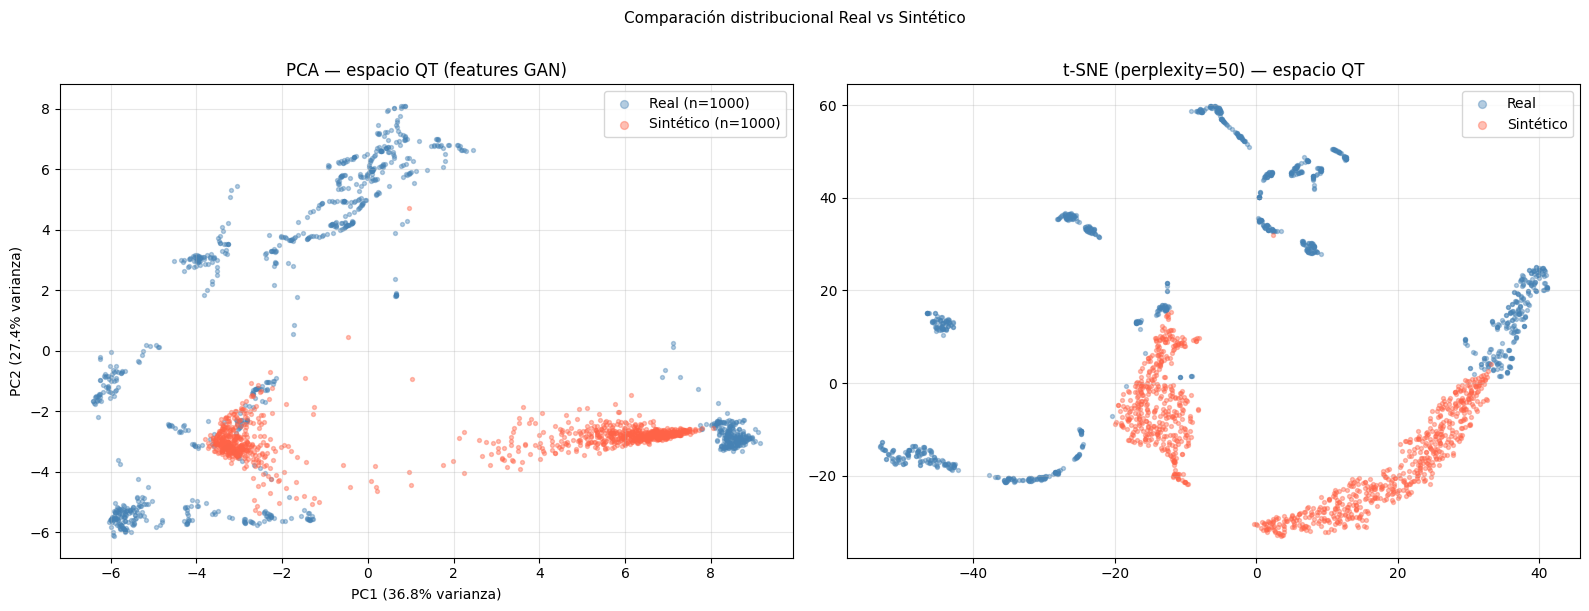

Diferencia de medias (por timestep×feature): 0.1343  ⚠️ 
Diferencia de stds   (por timestep×feature): 0.1228  ⚠️ 


In [21]:
# Muestrear 1000 ventanas de cada clase para las visualizaciones
n_plot  = min(1000, len(train_windows), n_synth)
rng     = np.random.default_rng(SEED)
ri      = rng.choice(len(train_windows),  n_plot, replace=False)
si      = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)      # (1000, seq_len × feature_dim)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

# Diferencia de estadísticas por timestep × feature
md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA: proyección 2D de las ventanas aplanadas
pca_model = PCA(n_components=2, random_state=SEED)
pr = pca_model.fit_transform(real_s)
ps = pca_model.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label=f"Real (n={n_plot})")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label=f"Sintético (n={n_plot})")
axes[0].set_title("PCA — espacio QT (features GAN)")
axes[0].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}% varianza)")
axes[0].legend(markerscale=2); axes[0].grid(True, alpha=0.3)

# t-SNE: proyección no lineal
comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label=f"Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label=f"Sintético")
axes[1].set_title(f"t-SNE (perplexity={perp}) — espacio QT")
axes[1].legend(markerscale=2); axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparación distribucional Real vs Sintético", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("tsne_timegan_final.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Diferencia de medias (por timestep×feature): {md:.4f}  {'✅' if md < 0.10 else '⚠️ '}")
print(f"Diferencia de stds   (por timestep×feature): {sd:.4f}  {'✅' if sd < 0.10 else '⚠️ '}")


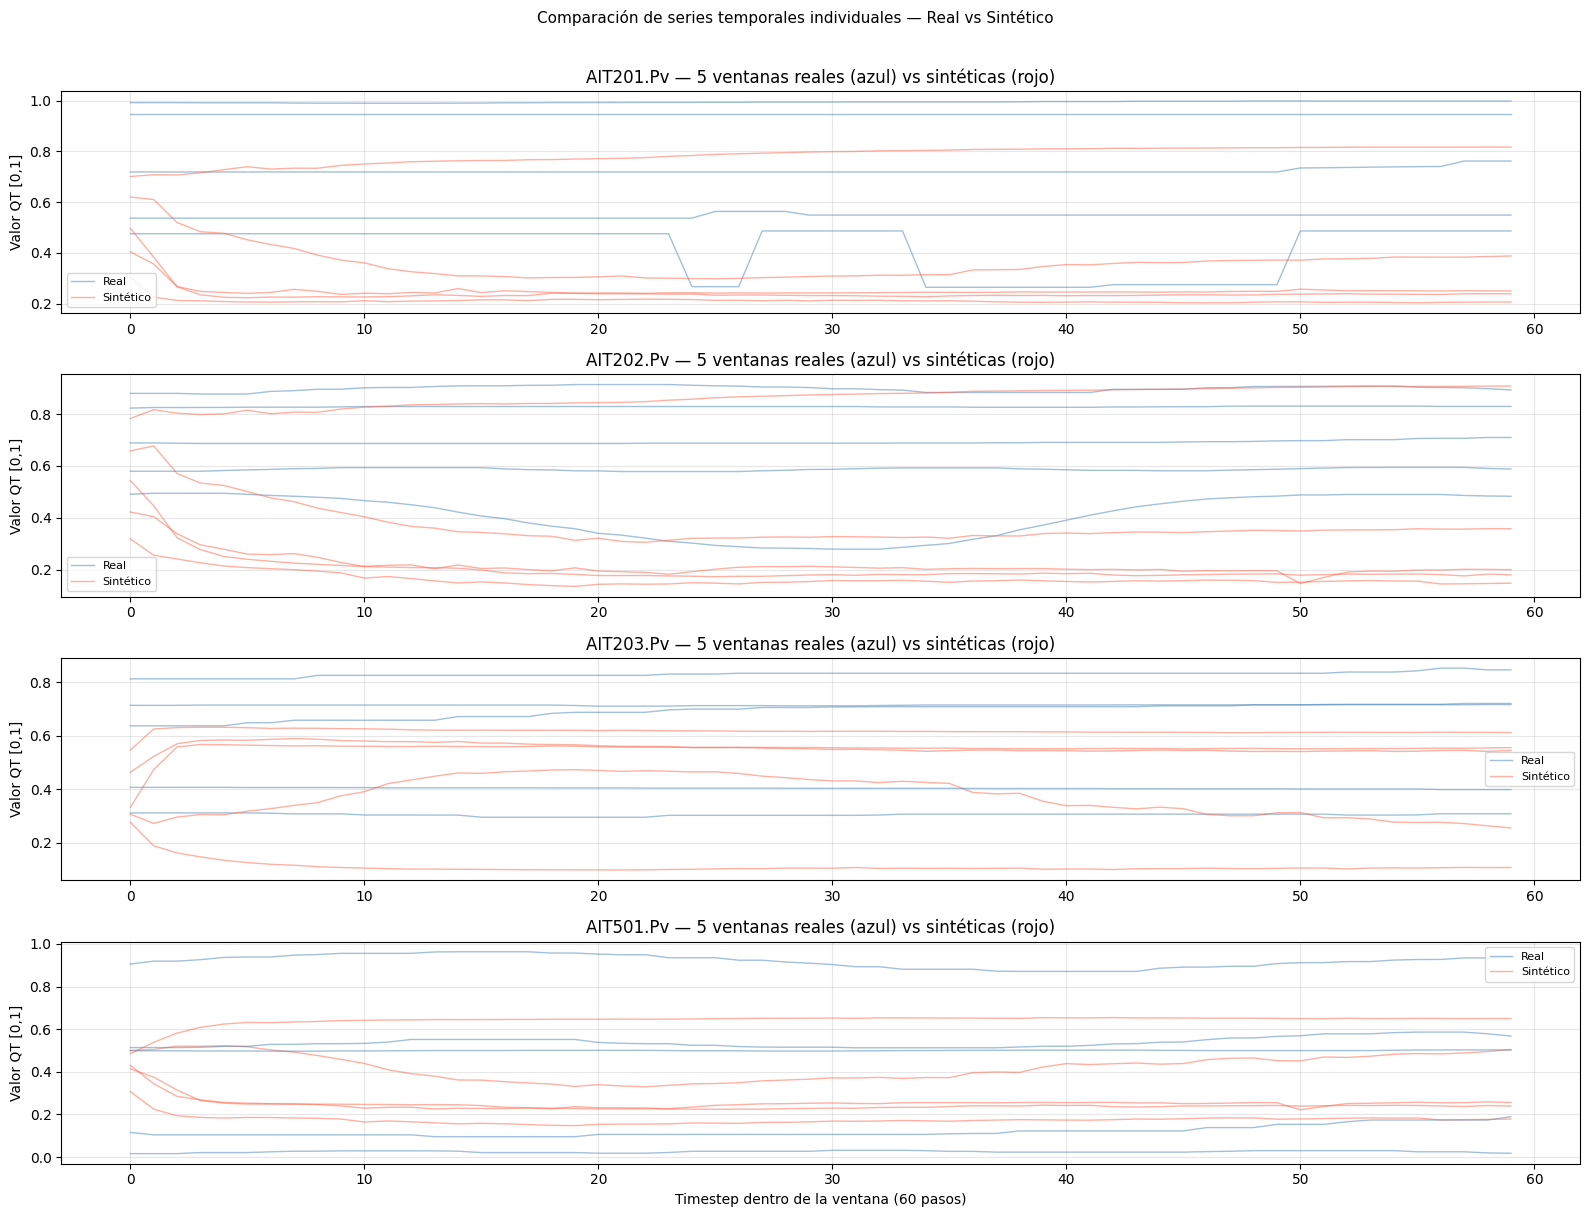

In [22]:
# Visualizar series sintéticas vs reales para features individuales
n_show = 5   # número de ventanas a mostrar
show_features = GAN_CONT_COLS[:4]  # las primeras 4 features GAN

fig, axes = plt.subplots(len(show_features), 1, figsize=(16, 3 * len(show_features)))
if len(show_features) == 1:
    axes = [axes]

rng_show = np.random.default_rng(SEED + 1)
real_idx  = rng_show.choice(len(train_windows),  n_show, replace=False)
synth_idx = rng_show.choice(len(synth_qt_clipped), n_show, replace=False)

for ax_idx, col in enumerate(show_features):
    feat_i = GAN_CONT_COLS.index(col)
    for k in range(n_show):
        axes[ax_idx].plot(train_windows[real_idx[k], :, feat_i],
                          color='steelblue', alpha=0.5, linewidth=1,
                          label="Real" if k == 0 else None)
        axes[ax_idx].plot(synth_qt_clipped[synth_idx[k], :, feat_i],
                          color='tomato', alpha=0.5, linewidth=1,
                          label="Sintético" if k == 0 else None)
    axes[ax_idx].set_title(f"{col} — {n_show} ventanas reales (azul) vs sintéticas (rojo)")
    axes[ax_idx].set_ylabel("Valor QT [0,1]")
    axes[ax_idx].legend(fontsize=8); axes[ax_idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestep dentro de la ventana (60 pasos)")
plt.suptitle("Comparación de series temporales individuales — Real vs Sintético",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


In [23]:
# RandomForest discriminador — métrica referencial
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

fi     = clf.feature_importances_
max_fi = fi.max()
top5   = np.argsort(fi)[-5:][::-1]

print("\n" + "="*60)
print(f"  AUC RandomForest discriminador = {auc:.4f}")
print("="*60)
print()
print("  NOTA: El AUC del RF con ventanas aplanadas NO es la métrica")
print("  primaria para evaluar GANs de series temporales. Con 840")
print("  dimensiones (60 pasos × 14 features), el RF detecta cualquier")
print("  diferencia sutil incluso cuando los datos son visualmente")
print("  indistinguibles. La métrica definitiva es el TSTR downstream.")
print()
print("  Top 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"    {GAN_CONT_COLS[ci]:20s} t={ti:2d}: importancia={fi[i]:.4f}")

print(f"\n  Importancia máxima: {max_fi:.4f}")
if max_fi < 0.05:
    print("  ✅  Importancias muy distribuidas — ninguna feature es trivialmente")
    print("      distinguible. Los datos sintéticos son de alta calidad.")
elif max_fi < 0.10:
    print("  ⚠️   Importancias moderadamente distribuidas.")
else:
    print("  ❌  Una feature domina — puede haber una feature con distribución problemática.")



  AUC RandomForest discriminador = 1.0000

  NOTA: El AUC del RF con ventanas aplanadas NO es la métrica
  primaria para evaluar GANs de series temporales. Con 840
  dimensiones (60 pasos × 14 features), el RF detecta cualquier
  diferencia sutil incluso cuando los datos son visualmente
  indistinguibles. La métrica definitiva es el TSTR downstream.

  Top 5 features más discriminativas:
    AIT201.Pv            t=39: importancia=0.0320
    AIT201.Pv            t=53: importancia=0.0275
    AIT202.Pv            t= 7: importancia=0.0272
    AIT201.Pv            t=12: importancia=0.0243
    LIT301.Pv            t=31: importancia=0.0215

  Importancia máxima: 0.0320
  ✅  Importancias muy distribuidas — ninguna feature es trivialmente
      distinguible. Los datos sintéticos son de alta calidad.


## 13. Guardado de artefactos

In [24]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

# Pesos de las 5 redes
for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

# Scalers
joblib.dump(qt,                   PROJECT_ROOT / "artifacts" / "scalers" / "timegan_quantile_transformer.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

# Catálogos empíricos
with open(TIMEGAN_MODEL_DIR / "fit_empirical.json", "w") as f:
    json.dump({
        col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
        for col, v in fit_empirical.items()
    }, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk, vv in v.items()} for k, v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=2)

# Configuración completa del modelo
config = {
    "version": "final",
    "descripcion": "TimeGAN versión final documentada — basada en v16",
    "decisiones_clave": [
        "QuantileTransformer(uniform): elimina mismatch distribucional G vs Embedder",
        "Separación FIT bimodales: síntesis empírica condicional en lugar de GAN",
        "Recovery lineal (sin Sigmoid): evita saturación del autoencoder",
        "R1 penalty (primer orden): reemplaza WGAN-GP incompatible con cuDNN RNNs",
        "Lazy R1 (cada 16 batches): reduce varianza del discriminador",
        "hidden_dim=128: mayor capacidad para regímenes operacionales de SWaT",
        "Feature matching media+std: previene mode collapse del generador",
        "no_grad en h_sup dentro del paso G: evita que supervisor aprenda sobre reales",
    ],
    "gan_cont_cols":  GAN_CONT_COLS,
    "fit_cols":       FIT_COLS,
    "continuous_cols_detector": continuous_cols,
    "discrete_cols":  discrete_cols,
    "window_size":    WINDOW_SIZE,
    "stride_timegan": TIMEGAN_STRIDE,
    "scaler":         "QuantileTransformer(n_quantiles=1000, output_distribution=uniform)",
    "feature_dim":    feature_dim,
    "hidden_dim":     hidden_dim,
    "latent_dim":     latent_dim,
    "num_layers":     num_layers,
    "G_STEPS":        G_STEPS,
    "D_STEPS":        D_STEPS,
    "G_CLIP":         G_CLIP,
    "D_CLIP":         D_CLIP,
    "R1_LAMBDA":      R1_LAMBDA,
    "R1_INTERVAL":    R1_INTERVAL,
    "gamma":          gamma,
    "eta":            eta,
    "FM_W":           FM_W,
    "lambda_r":       lambda_r,
    "lambda_s":       lambda_s,
    "epochs_embedder":   epochs_embedder,
    "epochs_supervisor": epochs_supervisor,
    "epochs_joint":      epochs_joint,
    "batch_size":        BATCH_SIZE,
    "train_windows":     len(train_windows),
    # Métricas del entrenamiento
    "embedder_mse_final":    float(embedder_history[-1]),
    "supervisor_loss_final": float(supervisor_history[-1]),
    "g_loss_final":          float(joint_g_history[-1]),
    "d_loss_final":          float(joint_d_history[-1]),
    "nash_g":                float(nash_g),
    "nash_d":                float(nash_d),
    "spikes_g35":            int(sum(1 for g in joint_g_history if g > 3.5)),
    # Métricas de calidad
    "diff_medias_qt":        float(md),
    "diff_stds_qt":          float(sd),
    "auc_rf_discriminador":  float(auc),
    "rf_importancia_max":    float(max_fi),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# Datos sintéticos generados
np.save(TIMEGAN_MODEL_DIR / "synth_qt.npy",          synth_qt_clipped)   # espacio QT
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)     # escala física GAN
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)      # escala física FIT
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)     # todas las continuas
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)      # escalado detector
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)     # discretas crudas
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)  # discretas one-hot
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)

# Historial de entrenamiento para análisis
pd.DataFrame({
    "epoch":  range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history,
    "d_loss": joint_d_history,
    "e_loss": joint_e_history,
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())
print()
print("Archivos generados:")
for f in sorted(TIMEGAN_MODEL_DIR.iterdir()):
    size = f.stat().st_size
    unit = "KB" if size < 1e6 else "MB"
    print(f"  {f.name:45s} {size/1e3 if size < 1e6 else size/1e6:6.1f} {unit}")


✅  Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned

Archivos generados:
  config.json                                      3.6 KB
  disc_empirical.json                              3.7 KB
  discrete_value_maps.json                         1.6 KB
  discriminator.pt                                 1.2 MB
  embedder.pt                                      1.1 MB
  fit_empirical.json                              82.1 KB
  generator.pt                                     1.2 MB
  recovery.pt                                      1.2 MB
  supervisor.pt                                  861.5 KB
  synth_all_physical.npy                          20.9 MB
  synth_disc_onehot.npy                           82.6 MB
  synth_disc_raw.npy                              23.6 MB
  synth_disc_summary.csv                           1.7 MB
  synth_fit_raw.npy                                8.2 MB
  s

## 14. Resumen final y próximos pasos

### Resumen del proceso de desarrollo

Esta versión final consolida los aprendizajes de ~25 versiones del modelo. Las
decisiones más impactantes, en orden de importancia:

1. **QuantileTransformer** (v8): resolvió el mismatch distribucional que bloqueaba
   el entrenamiento en todas las versiones anteriores (G loss plano en 2.19).

2. **Separación de features FIT bimodales** (v7): los sensores de flujo no pueden
   ser modelados por un GAN continuo. Síntesis empírica condicional.

3. **Recovery lineal** (v4): eliminar Sigmoid en la salida del Recovery redujo el
   MSE del embedder de 0.064 a < 0.0002.

4. **R1 en lugar de WGAN-GP** (v13): WGAN-GP requiere doble backward en GRUs,
   incompatible con cuDNN. R1 es equivalente y 20x más rápido.

5. **hidden_dim=128** (v16): permitió al modelo capturar la multimodalidad del
   espacio operacional de SWaT. Primer descenso del AUC RF.

### Próximo paso: evaluación TSTR

La métrica definitiva para validar los datos sintéticos en el contexto de la tesis
es el **TSTR (Train on Synthetic, Test on Real)**:

```
Experimento A: entrenar detector conv1d solo con datos reales
Experimento B: entrenar detector conv1d con datos reales + datos sintéticos
Experimento C: entrenar detector conv1d solo con datos sintéticos

Evaluar en test real (con anomalías etiquetadas):
  → si F1(B) > F1(A): la augmentación con datos sintéticos mejora la detección
  → si F1(C) ≈ F1(A): los sintéticos capturan suficientemente la distribución real
```

Los archivos `synth_for_detector.npy` y `X_synth_disc` están listos para
ser usados directamente en el pipeline del detector.
